In [1]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
df=pd.read_excel("toydata.xlsx")
df.head()

,x1,x2,y
0,0.77,-1.14,0
1,-0.33,1.44,0
2,0.91,-3.07,0
3,-0.37,-1.91,0
4,-1.84,-1.13,0


In [3]:
df.shape

(100, 3)

In [4]:
x_train=df[["x1","x2"]].values

In [5]:
y_train=df["y"].values

In [6]:
np.bincount(y_train)

array([50, 50], dtype=int64)

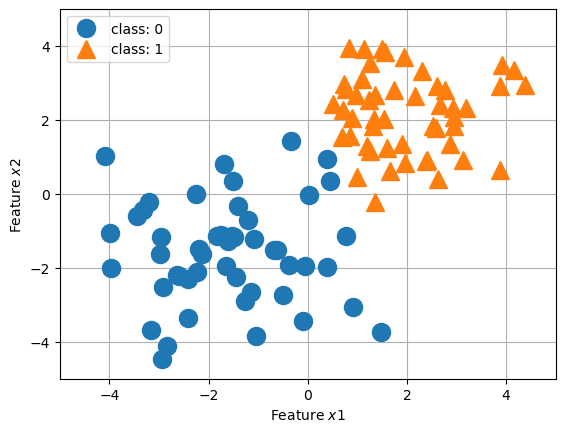

In [7]:
plt.plot(x_train[y_train==0,0],
         x_train[y_train==0,1],
         label="class: 0",
         marker="o"
         ,linestyle="",
         markersize=13
        )
plt.plot(x_train[y_train==1,0],
         x_train[y_train==1,1],
         label="class: 1",
         marker="^",
         linestyle="",
         markersize=13
        )
plt.legend(loc=2)
plt.xlim([-5,5])
plt.ylim([-5,5])
plt.xlabel("Feature $x1$")
plt.ylabel("Feature $x2$")
plt.grid()
plt.show()

In [8]:
x_train.shape

(100, 2)

In [9]:
class perceptron:
    def __init__(self,num_feature):
        self.num_feature=num_feature
        self.weight=[0.0 for _ in range(num_feature)]
        self.bias=0.0
    def forward(self,x):
        z=self.bias
        for i,j in enumerate(self.weight):
            z+=x[i]*j
        if z>0:
            return 1
        else:
            return 0
    def update(self,x,y_true):
        error=y_true-self.forward(x)
        self.bias+=error
        for i in range(self.num_feature):
            self.weight[i]+=error*x[i]
        return error
    def train(self,x_train,y_train,epochs):
        for epoch in range(epochs):
            error=0
            for i in range(len(x_train)):
                error+=abs(self.update(x_train[i],y_train[i]))
                
            print(f"Epoch {epoch+1}: Error: {error} Weight {self.weight,self.bias}")
    def boundry(self,x_train,y_train):
        plt.plot(x_train[y_train==0,0],
         x_train[y_train==0,1],
         label="class: 0",
         marker="o"
         ,linestyle="",
         markersize=1
        )
        plt.plot(x_train[y_train==1,0],
                 x_train[y_train==1,1],
                 label="class: 1",
                 marker="^",
                 linestyle="",
                 markersize=1
                )
        x1=[-5,5]
        x2=-(self.bias+x1[0]*self.weight[0])/self.weight[1]
        x3=-(self.bias+x1[1]*self.weight[0])/self.weight[1]
        plt.plot(x1,[x2,x3])
        plt.legend(loc=2)
        plt.xlim=[-5,5]
        plt.ylim=[-5,5]
        plt.xlabel("Feature $x1$")
        plt.ylabel("Feature $x2$")
        plt.grid()
        plt.show()

In [10]:
model=perceptron(2)

In [45]:
model.train(x_train,y_train,8)

Epoch 1: Error: 1 Weight ([3.88, 0.65], 1.0)
Epoch 2: Error: 6 Weight ([2.6999999999999997, 2.5700000000000003], -3.0)
Epoch 3: Error: 2 Weight ([3.32, 2.0800000000000005], -3.0)
Epoch 4: Error: 2 Weight ([3.62, 2.670000000000001], -3.0)
Epoch 5: Error: 1 Weight ([3.24, 1.7200000000000009], -4.0)
Epoch 6: Error: 0 Weight ([3.24, 1.7200000000000009], -4.0)
Epoch 7: Error: 0 Weight ([3.24, 1.7200000000000009], -4.0)
Epoch 8: Error: 0 Weight ([3.24, 1.7200000000000009], -4.0)


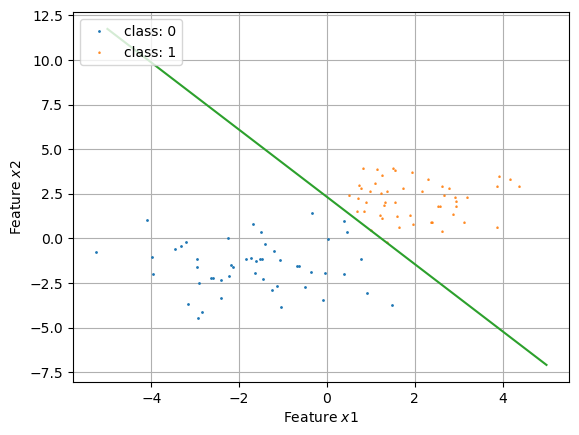

In [46]:
model.boundry(x_train,y_train)

# Tensor pytorch

In [11]:
import torch as t

In [12]:
tensor=t.tensor([[3,4,5],[6,7,8]])

In [13]:
tensor

tensor([[3, 4, 5],
        [6, 7, 8]])

In [14]:
tensor.shape

torch.Size([2, 3])

In [15]:
tensor.dtype

torch.int64

In [17]:
new=t.tensor([4,5,6,7])

In [19]:
new+4

tensor([ 8,  9, 10, 11])

# new perceptron by torch for easy computation 

In [22]:
class perceptron:
    def __init__(self,num_feature):
        self.num_feature=num_feature
        self.weight=t.zeros(num_feature)
        self.bias=t.tensor([0.0])
    def forward(self,x):
        x=t.tensor(x)
        z=self.bias
        z+=x.dot(self.weight)
        if z>0:
            return t.tensor([1])
        else:
            return t.tensor([0])
    def update(self,x,y_true):
        error=y_true-self.forward(x)
        self.bias+=error
        self.weight+=error*x
        return error
    def train(self,x_train,y_train,epochs):
        for epoch in range(epochs):
            error=0
            for i in range(len(x_train)):
                error+=abs(self.update(x_train[i],y_train[i]))
                
            print(f"Epoch {epoch+1}: Error: {error} Weight {self.weight,self.bias}")
    def boundry(self,x_train,y_train):
        plt.plot(x_train[y_train==0,0],
         x_train[y_train==0,1],
         label="class: 0",
         marker="o"
         ,linestyle="",
         markersize=1
        )
        plt.plot(x_train[y_train==1,0],
                 x_train[y_train==1,1],
                 label="class: 1",
                 marker="^",
                 linestyle="",
                 markersize=1
                )
        x1=[-5,5]
        x2=-(self.bias+x1[0]*self.weight[0])/self.weight[1]
        x3=-(self.bias+x1[1]*self.weight[0])/self.weight[1]
        plt.plot(x1,[x2,x3])
        plt.legend(loc=2)
        plt.xlim=[-5,5]
        plt.ylim=[-5,5]
        plt.xlabel("Feature $x1$")
        plt.ylabel("Feature $x2$")
        plt.grid()
        plt.show()

In [24]:
m=perceptron(2)
m.forward([4.0,3.0])

tensor([0])